In [1]:
#The whole cell ran successfully

#we can input this all into forRealSVM_starting once I've created the csv file

# imports the json module, which handles json files
import json

#tries to open my json file
try:
    with open('acndata_sessions (7).json') as f:

        #uses .load to parse the file's contents into a list or dictionary. If the json file is valid, it gets stored in "data"
        data = json.load(f)

        # if  the file is invalid or corrupted, it catches the JSONDecodeError
        #e is an exception object that gets created when the error occurrs. it contains details about where and why the json parsing failed
except json.JSONDecodeError as e:
    #prints detailed error feedback if the file is malformed(figure out what they mean by malformed) 
    #(I don't think it's malformed cuz this prints nothing)
    print(f"Error decoding JSON: {e}") 
    #the line number, column, and character position where the problem occurred
    #this is something called an "f-string", in which curly brackets let you embed a variable directly into a string. e.lineno is the...
    #...exact line in the original JSON file where the error occurred
    print(f"Error at line {e.lineno}, column {e.colno}, character {e.pos}") 


In [2]:
import pandas as pd

# Load the JSON file
# the lack of a "try" statement here makes it assume there are no errors, so we can't do the error handling here that we did in the previous block
with open('acndata_sessions (7).json', 'r') as file:
    data = json.load(file)

# Initialize a list to store the EV charging session data
sessions_list = []





# Loop through the items and extract relevant fields
# here, 'items' is not something I created but a LIST that already exists in my natural json file(go to the Jupyter json file and I will see..
# ...it inside "root", alongside "meta"
for session in data['_items']:
    # Extract general session data: this turns every charging session(every list) inside 'items' in "data" into a dictionary(a single, full row)
    session_data = {   # filling the session_data list and TURNING IT INTO A DICTIONARY
        "_id": session.get("_id"),
        "clusterID": session.get("clusterID"), #ID of a specific group of EV supply equipment, like the ID of a single garage
        "connectionTime": session.get("connectionTime"), # RTF 1123 format
        "disconnectTime": session.get("disconnectTime"),
        "doneChargingTime": session.get("doneChargingTime"),
        "kWhDelivered": session.get("kWhDelivered"),
        "sessionID": session.get("sessionID"),
        "siteID": session.get("siteID"),
        "spaceID": session.get("spaceID"), #ID of the parking space
        "stationID": session.get("stationID"),
        "timezone": session.get("timezone"),
        "userID": session.get("userID") #only exists if the charging session is claimed using the mobile app
    }

    # Extract user inputs if available(this is INSIDE the larger for loop!)
    if session.get("userInputs"): #this is checking if, for each charging session that the for loop loops through, the user inputted anything
        user_inputs = session["userInputs"][0]  # Assuming the first user input if multiple
        session_data.update({
            #adds more fields to the dictionary because there are more fields in this case
            "WhPerMile": user_inputs.get("WhPerMile"),
            "kWhRequested": user_inputs.get("kWhRequested"),
            "milesRequested": user_inputs.get("milesRequested"),
            "minutesAvailable": user_inputs.get("minutesAvailable"),
            "modifiedAt": user_inputs.get("modifiedAt"),
            "paymentRequired": user_inputs.get("paymentRequired"),
            "requestedDeparture": user_inputs.get("requestedDeparture"),
            "userInput_userID": user_inputs.get("userID")
        })

          
    # Append session data to the list
    sessions_list.append(session_data) #we do this a bunch of times since we're looping, which gives us a full list of charging sessions


#WE HAVE NOW EXITED THE FOR LOOP
# Convert sessions_list(which is now a dictionary) to a pandas DataFrame
df_sessions = pd.DataFrame(sessions_list)
# Convert df_sessions(the dataframe of my sessions_list that I made) into a CSV FILE
df_sessions.to_csv('session_data.csv', index=False) #index=False just means it won't include the row index as its own column in the file

In [1]:
import pandas as pd
df = pd.read_csv('newest_data.csv')
print(df.head(40))

    connection_minute  connection_hour  connection_day_of_month  \
0                  17                6                       25   
1                   0                7                       25   
2                  43                7                       25   
3                  26                8                       25   
4                  12                9                       25   
5                  46                9                       25   
6                  25               10                       25   
7                   8               11                       25   
8                  51               11                       25   
9                  39               12                       25   
10                 21               13                       25   
11                 58               13                       25   
12                 40               14                       25   
13                 20               15                       2

In [3]:
#don't run this cell

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from datetime import timedelta

# Load the dataset
df = pd.read_csv('newest_data.csv')

# Convert connectionTime and doneChargingTime(features/columns of df) to datetime
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
# datetime Format: YYYY-MM(as a number)-DD(day of the month) HH:MM:SS
df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])

# df.head WORKS! IT PRINTS CONNECTION TIME AND DONE CHARGING TIME AS WHAT I CONVERTED IT TO!
# print(df.head())


# Parameters
attack_percentage = 0.20  # 10% of stations will be attacked per day(I have no idea wtf is going on here)
# .unique() returns an array of all the distinct values found in an array.
stations = df['spaceID'].unique() #the variable "station" is a list of the unique rows in the spaceID column(unique parking space has its own charging station)
days = df['connectionTime'].dt.date.unique()  # the variable "days" is a list of the unique dates in the connectionTime column

# Define attack ranges
connection_time_increase_range = 15  # 15 minutes
done_charging_time_decrease_range = 15  # 15 minutes
demand_change_factor = 0.4  # 40% increase(ask if demand change factor is miles requested and Kwh requested).

# Initialize columns
df['is_attack'] = 0 # creates a NEW COLUMN called 'is_attack' that equals 0 if it's a cyberattack. Fills this column with zeroes.
df['changed_connectionTime'] = df['connectionTime'] #this makes all the connectionTimes be copied into a new column called changed_connectionTime
df['changed_doneChargingTime'] = df['doneChargingTime'] #this copies all the doneChargingTimes into a new column called changed_doneChargingTime
df['changed_kWhDelivered'] = df['kWhDelivered'] #this copies all the kwHDelivered into a new column called changed_kWhdelivered
df['multiclass'] = 0  # Default class 0 for no attack. class 1 will equal attack, and I'm not sure what the other classes will be, but there will...
#...be more because I will be putting this into a multiclass support vector classifier

# Intelligent attack function with multiclass logic
# This function makes it so that if the value in changed_connectionTime doesn't equal the value in connectionTime, then that row has 
#...had a changedConnectionTime
def intelligent_attack(row, attack_types):
    if 'increase_start' in attack_types: 
        increment = timedelta(minutes=connection_time_increase_range) #increments the timedelta by 15 minutes (using the timedelta function)
        row['changed_connectionTime'] = row['connectionTime'] + increment #changes a value in the changed_connectionTime to a value that is 15 min...
        #...higher than a normal connection time
    if 'decrease_done' in attack_types: #if charging time ends earlier than normal
        decrement = timedelta(minutes=done_charging_time_decrease_range) #decrements the timedelta by 15 minutes
        #there is a timedelta function somewhere
        row['changed_doneChargingTime'] = row['doneChargingTime'] - decrement #changes a value in the changed_doneChargingTime column to...
        #...something that is one decrement lesser than the original doneChargingTime
    if 'change_demand' in attack_types: #increases the demand by 40% if a change in demand s found in the list called attack_types
        demand_change = row['kWhDelivered'] * demand_change_factor #creates a value that is a single kwhDelivered entry times the demand change ...
        #...factor of 0.4
        row['changed_kWhDelivered'] = row['kWhDelivered'] + demand_change #in changed_kWhDelivered column of the inputted row, the value in that...
        #...column will become the KwhDelivered column of row plus 40% of itself.
     # Set the appropriate class based on the types of attacks applied
    if attack_types == ['increase_start']:
        row['multiclass'] = 1 #class 1 means a cyberattack identified by an increase_start time
    elif attack_types == ['decrease_done']:
        row['multiclass'] = 2 # class 2 means a cyberattack identified by the doneChargingTime decreasing
    elif attack_types == ['change_demand']:
        row['multiclass'] = 3 # class 3 means a cyberattack identified by the demand of energy and mileage increasing by 40%
    elif attack_types == ['increase_start', 'change_demand']:
        row['multiclass'] = 4 # class 4 means a cyberattack identified by both an increase in start time and an increase in demand.
    elif attack_types == ['increase_start', 'change_demand', 'decrease_done']:
        row['multiclass'] = 5 # class 5 means a cyberattack identified by an increase in start time, an increase in demand, and a decrease in done time

    row['is_attack'] = 1
    return row
# End of the function






# Apply attacks per day(makes the variable attacked_stations=how MANY stations were attacked per unique day)
for day in days:
    day_df = df[df['connectionTime'].dt.date == day] # creates a new dataframe that is a list of all entries in the "connectionTime" column of df... 
    #...where the entries in that column have a unique date.
    daily_stations = day_df['spaceID'].unique() # daily stations is a list of the unique parking spaces that ALSO have a unique day
    #max() returns the maximum of the numbers you insert, so if the attack perc. times the number of daily stations is less than one, it will at least
    #...return 1. Otherwise, it will return the exact whole number of daily stations that were attacked.
    num_attacked = max(1, int(attack_percentage * len(daily_stations))) # num_attacked is the maximum between 1 and the number of "daily_stations"...
    #...that exist.
    # random is a module. 
    attacked_stations = random.sample(list(daily_stations), num_attacked) # randomly selects a specified number(num_attacked)...
    #...of unique elements from a list. It doesn't select the attacked stations, it selects the NUMBER of stations that were attacked, which thus 
    #...shows us how MANY stations were attacked per unique day. atacked_stations includes stations that were not attacked.

        #Space ID = station in this situation because attacked_stations is a list of STATIONS, not charging sessions
    for station in attacked_stations:
        # station_rows = entries in the SpaceID column that equal the "attacked_station"/spaceID we are currently looping
        #through AND whose connection day equals
        #...the day that the bigger loop is looping through
        station_rows = df[(df['spaceID'] == station) & (df['connectionTime'].dt.date == day)] #specific row in the larger dataframe where we have an
        #...attacked station space and attacked station day, but not necessarily attacked
        for index, row in station_rows.iterrows(): #applies itself to ALL the chosen rows of df(now called station rows) one at a time
            attack_combination = random.choice([ #selects a random element from each list of entries of each type of attack
                ['increase_start'],
                ['decrease_done'],
                ['change_demand'],
                ['increase_start', 'change_demand'],
                ['increase_start', 'change_demand', 'decrease_done']
            ])
            df.loc[index] = intelligent_attack(row, attack_combination) #each index of each row in df that matches a day and time of an attack
            #now gets the intelligent attack function applied to it. which type of attack the attack function applies depends on which combination
            #of attacks this loop iteration finds in attack_combination


#End of triple nested for loop

# Save the modified dataset
df.to_csv('session_data_project_with_multiclass_attack_15_15_40.csv', index=False)

KeyError: 'connectionTime'

In [5]:
# don't run this cell

import numpy as np #helps with doing math

!pip install scikit-learn

import sklearn

import pandas as pd # allows us to read the csv file

from sklearn.svm import SVC #getting the support vector classifier from skitlearn

df = pd.read_csv('current_data.csv')

# Convert connectionTime and doneChargingTime columns to datetime format
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])

# Suggestion 1: Calculate Duration
# Calculate the duration in minutes between connectionTime and doneChargingTime
df['duration'] = (df['doneChargingTime'] - df['connectionTime']).dt.total_seconds() / 60  # Duration in minutes

# Suggestion 2: Extract Temporal Features for both connectionTime and doneChargingTime, including minutes
# Temporal features for connectionTime
df['connection_minute'] = df['connectionTime'].dt.minute
df['connection_hour'] = df['connectionTime'].dt.hour
df['connection_day_of_month'] = df['connectionTime'].dt.day  # Day of the month
df['connection_month'] = df['connectionTime'].dt.month #creating new columns for each part of the bigger time column

# Temporal features for doneChargingTime
df['done_minute'] = df['doneChargingTime'].dt.minute
df['done_hour'] = df['doneChargingTime'].dt.hour
df['done_day_of_month'] = df['doneChargingTime'].dt.day  # Day of the month
df['done_month'] = df['doneChargingTime'].dt.month

# Clean the spaceID column to extract only numeric values
df['spaceID'] = df['spaceID'].str.extract(r'(\d+)', expand=False).astype(int)

# Select only the specified columns
final_columns = [
    'connection_minute', 'connection_hour', 'connection_day_of_month', 'connection_month',
    'done_minute', 'done_hour', 'done_day_of_month', 'done_month', 'spaceID', 'duration', 'kWhDelivered', 'is_attack', 'multiclass'
]
df = df[final_columns] # THIS LINE IS WHAT DROPS THE COLUMNS FROM THE ACN WEBSITE THAT WE DON"T WANT(hence we only have 13 columns)

# Remove rows with any NaN values
df = df.dropna()

# Display the resulting DataFrame with selected features
print(df.head(10))

# Save the modified DataFrame to a new CSV file
df.to_csv('attack_dataset_working_test.csv', index=False)

data = pd.read_csv('attack_dataset_working_test.csv')

print(data.head())
#connection minute: the minute when the EV plugged in(I think)
#connection hour: the hour when the EV plugged in(military time?)
#connection day of month: day of the month when the EV plugged in(I think)
#connection month: month when the EV plugged in(I think)
#done_minute: minute when the last non-zero current draw was recorded
#done hour: hour when the last non-zero current draw was recorded
# done day of month: day of the month when the last non-zero current draw was recorded(I think)
# done month: month when the last non-zero current draw was recorded(I think)
# SpaceID: unique identifier of the parking space(I'm sure)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


KeyError: 'connectionTime'

In [2]:
data = df
num_columns = len(data.columns) # same nmber of columns, but way more rows(23,000)
num_rows = len(data)
#This cell shows us that there are 14193 charging sessions(samples) and 13 features of charging sessions in the dataset
print("There are: ", num_rows,  "rows. There are: ", num_columns, "columns.") #remember to use commas, not pluses

There are:  233280 rows. There are:  13 columns.


In [3]:
# 12 features
#We have our general X and Y now; next step: fit the support vector machine, specifically the support vector classifier, on X and Y
!pip install imbalanced-learn

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# : before the comma means all rows, : after the comma means all columns
X = (data.iloc[:,:12]).values # all the rows(n samples = 6384) and the first 12 columns(I'm sure this is correct)
     #data.iloc accesses the actual rows and columns of a dataset
#nSamples is all the rows, nFeatures is all the columns!

#ravel turns this into a 1d array that we can use for the classifier
Y = data.iloc[:,-1].values #all the rows again, but only the second to last column(specifies if it's an attack) 
#the lack of a colon makes sure it only includes the last column; putting a colon there would make it access all columns except the last

import torch
from torch.utils.data import Dataset, DataLoader

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, Y_balanced = smote.fit_resample(X, Y)

# Create a custom Dataset class
class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

        
# Create the full dataset using your CustomDataset class
full_dataset = CustomDataset(X_balanced, Y_balanced)  # X and y are your full features and labels

# Split into train (70%), validation (15%), test (15%)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size]
)




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [14]:
print((data['multiclass']==0).sum())
print((data['multiclass']==1).sum())
print((data['multiclass']==2).sum())
print((data['multiclass']==3).sum())
print((data['multiclass']==4).sum())
print((data['multiclass']==5).sum())

116640
23328
23328
23328
23328
23328


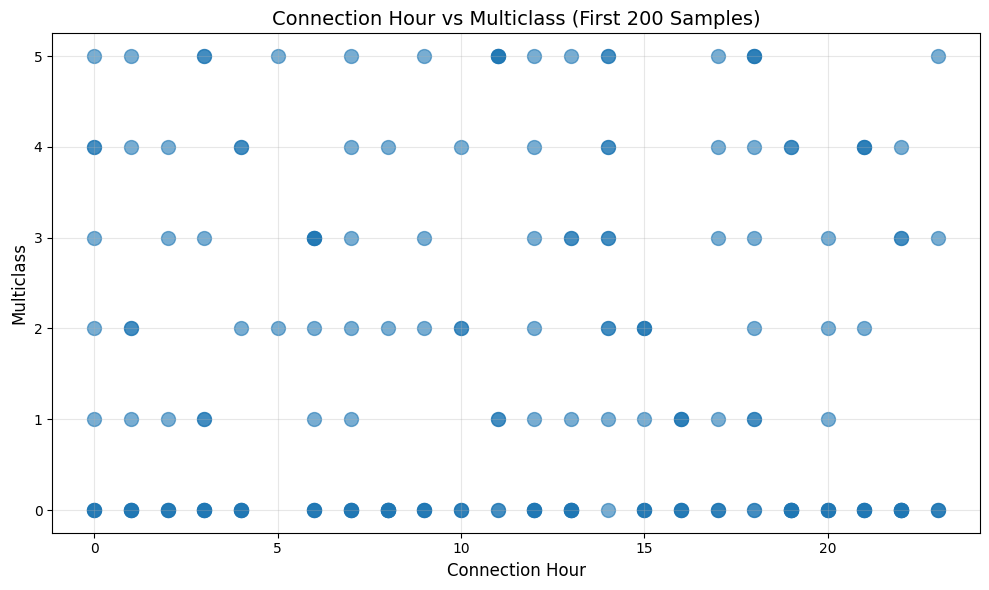

In [8]:
#visualizing the data for connection_hour
import matplotlib.pyplot as plt

# Assuming your dataframe is called 'df'
# Get first 20 samples
data_subset = data.head(200)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(data_subset['connection_hour'], data_subset['multiclass'], 
            alpha=0.6, s=100)

plt.xlabel('Connection Hour', fontsize=12)
plt.ylabel('Multiclass', fontsize=12)
plt.title('Connection Hour vs Multiclass (First 200 Samples)', fontsize=14)
plt.grid(True, alpha=0.3)

# Optional: Set y-axis to show integer values only
plt.yticks(data_subset['multiclass'].unique())

plt.tight_layout()
plt.show()

In [4]:
!pip install torch


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install torchvision


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #guarantees that this will run on GPUs

#hyperparameters
input_size = 12 #number of features
hidden_size = [128, 64] # number of neurons in the hidden layer
num_classes = 6
num_epochs = 30 #number of times through the entire dataset
batch_size = 500
learning_rate = 0.0001

patience = 5 #minimum number of epochs to wait for improvement
min_delta = 0.001 #minimum amount of learning to qualify as improvement(note that our learning rate is 0.001)

from torch.utils.data import DataLoader, TensorDataset




# Create DataLoader
train_loader = torch.utils.data.DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle=False)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        # self.l1 means the first layer of this class(the NeuralNet class) (this is the first hidden layer)
        self.l1 = nn.Linear(input_size, hidden_size) #input size is the input_size and output size is the hidden_size for this first layer
        self.relu = nn.ReLU() #activation function for the first layer is ReLu
        self.l2 = nn.Linear(hidden_size, hidden_size) #layer 2(the second hidden layer)
        self.relu = nn.ReLU()
        self.l3 = nn.Linear(hidden_size, num_classes) #layer 3(the final output layer, no ReLu

    def forward(self, x): #X is a sample from the dataset
        out = self.l1(x) # defining and updating the output by applying math to it
        out = self.relu(out) 
        out = self.l2(out) # don't apply softmax here because cross entropy will apply that for us later
        out = self.relu(out)
        out = self.l3(out)
        return out


model = NeuralNet(input_size, hidden_size[0], num_classes)

        

In [14]:
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False


criterion = nn.CrossEntropyLoss()  # Note: PyTorch doesn't have built-in FocalLoss
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)



In [15]:
import numpy as np

n_total_steps = len(train_loader) #length of the training loader

# for loop to loop through the epochs(it will do this for every training epoch):
for epoch in range(num_epochs):

    for i, (batch_X, batch_Y) in enumerate(train_loader):
    # this is the forward pass
        outputs = model(batch_X) # because we are training now, not getting the accuracy yet
    # outputs is basically Y_train_preds here
        loss = criterion(outputs, batch_Y)

    #this is the backwards pass
        optimizer.zero_grad() #running gradient descent to get new weights
        loss.backward() # this calls the backward function from torch.nn.CrossEntropyLoss(), performing the backwards pass
        optimizer.step() # this updates the weights for us

        #printing the loss and epochs
        if (i+1) % 5 == 0:
            print(f"epoch {epoch+1}/{num_epochs}, step {i+1}/{n_total_steps}, loss = {loss.item():.4f}")

            # ===== VALIDATION PHASE =====
    model.eval()  # Set model to evaluation mode
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_Y)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}')
    
    # ===== EARLY STOPPING CHECK =====
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved with val_loss: {val_loss:.4f}")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# Load the best model before testing
model.load_state_dict(torch.load('best_model.pth'))
print("Loaded best model for testing")

# ===== TESTING PHASE =====
from sklearn.metrics import accuracy_score, confusion_matrix

model.eval()  # Set model to evaluation mode    

val_loss = 0
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

#testing
with torch.no_grad():

    all_predictions = []
    all_labels = []

    n_correct = 0
    n_samples = 0
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0

    val_loss /= len(val_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}')
    
    # ===== EARLY STOPPING CHECK =====
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved with val_loss: {val_loss:.4f}")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        early_stop = True

# Load the best model before testing
model.load_state_dict(torch.load('best_model.pth'))
print("Loaded best model for testing")

# ===== TESTING PHASE =====
from sklearn.metrics import accuracy_score, confusion_matrix

model.eval()  # Set model to evaluation mode
with torch.no_grad():
    all_predictions = []
    all_labels = []
    n_correct = 0
    n_samples = 0
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0
    
    for X, Y in test_loader:
        outputs = model(X)
        _, predictions = torch.max(outputs, 1)
        
        n_samples += Y.shape[0]
        n_correct += (predictions == Y).sum().item()
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(Y.cpu().numpy())
    
        true_positives += (((predictions == 1)&(Y==1))|((predictions==2)&(Y==2))|((predictions==3)&(Y==3))|((predictions==4)&(Y==4))|((predictions==5)&(Y==5))).sum().item()
        false_positives += ((predictions!=0)&(Y == 0)).sum().item()
        true_negatives += ((predictions == 0)&(Y==0)).sum().item()
        false_negatives += ((predictions == 0)&(Y!=0)).sum().item()
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Calculate metrics
    acc = 100.0 * n_correct/n_samples
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n===== FINAL TEST RESULTS =====")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    

 

    

epoch 1/30, step 5/980, loss = 6.8956
epoch 1/30, step 10/980, loss = 4.9400
epoch 1/30, step 15/980, loss = 3.8667
epoch 1/30, step 20/980, loss = 2.9839
epoch 1/30, step 25/980, loss = 2.5027
epoch 1/30, step 30/980, loss = 1.9989
epoch 1/30, step 35/980, loss = 2.0914
epoch 1/30, step 40/980, loss = 2.1257
epoch 1/30, step 45/980, loss = 1.9630
epoch 1/30, step 50/980, loss = 1.9573
epoch 1/30, step 55/980, loss = 1.9564
epoch 1/30, step 60/980, loss = 1.9617
epoch 1/30, step 65/980, loss = 1.8964
epoch 1/30, step 70/980, loss = 1.8972
epoch 1/30, step 75/980, loss = 1.9154
epoch 1/30, step 80/980, loss = 1.9324
epoch 1/30, step 85/980, loss = 1.9245
epoch 1/30, step 90/980, loss = 1.8551
epoch 1/30, step 95/980, loss = 1.8621
epoch 1/30, step 100/980, loss = 1.8646
epoch 1/30, step 105/980, loss = 1.8747
epoch 1/30, step 110/980, loss = 1.8804
epoch 1/30, step 115/980, loss = 1.8637
epoch 1/30, step 120/980, loss = 1.8498
epoch 1/30, step 125/980, loss = 1.8934
epoch 1/30, step 130

In [ ]:
#don't run unless necessary

for X, Y in test_loader: # Y in test_loader is a batch of Y_train_tensor
        outputs = model(X)

        #value, index
        _, predictions = torch.max(outputs, 1) #max finds the class with the highest score for each sample, then stores the index of that maximum 
        #value in predictions. So predictions is a 1d array with each element being a value 1 thru 5, so each value in predictions array is a class
        
        n_samples += Y.shape[0] # gives us the number of samples in the current batch
        n_correct += (predictions == Y).sum().item() #for each correct prediction, add 1

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(Y.cpu().numpy())
    


        true_positives += (((predictions == 1)&(Y==1))|((predictions==2)&(Y==2))|((predictions==3)&(Y==3))|((predictions==4)&(Y==4))|((predictions==5)&(Y==5))).sum().item()
        false_positives += ((predictions!=0)&(Y == 0)).sum().item()
        true_negatives += ((predictions == 0)&(Y==0)).sum().item()
        false_negatives += ((predictions == 0)&(Y!=0)).sum().item()

        # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    

    # calculate total accuracy
    acc = 100.0 * n_correct/n_samples
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Recall: {recall} Accuracy: {acc}  Recall: {recall} F1 score: {f1_score}  Confusion Matrix: {cm}")
 

    

AttributeError: 'Tensor' object has no attribute 'head'